
Before we construct the proper RAW model, we need to remember that typcially subcarrier spacings are **15kHz for LTE, 30/60kHz for Higher-Throughput and 60/120kHz for mmWave**, the decisive factor is bandwidth since it combines:
$$\text{Bandwidth} = \text{fft\_size} \times \text{subcarrier\_spacing}$$


There are 12 subcarriers in each PRB (Physical Resource Block), and 14 OFDM symbols in each  slot, and it is not related to `resourcegrid()` object that we need to utilize in our model


The research model we are trying to build is a basic Detnet with full Sionna PHY chain (OFDM, 5G LDPC, CDL channel Estimation and Equalization),
**Talker ---->hop1--->Relay (Base Station)--->hop2-->Listener**

Each hop is an independent OFDM link, that will be assigned with resource grid, CDL channel, encoder and decoder, and relay decodes hop 1, and only if it
decodes successully once it re-encode and forard to hop2, acting as a **DetNet's store and foward semantics.**

Since we utilize PHY layer, the deterministic schedular reserves fixed 2-slot cycle (slot 0 is Talker==>Relay, slot 1 is Relay==>Listener), this is the baseline of DetNet-style scheduling.

We will add redundancy and replication in the later stage

The simulation environment relies on Sionna 2.0.1


In [1]:
import numpy as np
#Not sure we still need pytorch, but keep this thing in mind
import torch
from sionna.phy import Block
from sionna.phy.mapping import BinarySource, Mapper, Demapper
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers
from sionna.phy.mimo import StreamManagement
from sionna.phy.channel.tr38901 import CDL, Antenna
from sionna.phy.channel import OFDMChannel
from sionna.phy.utils import ebnodb2no, compute_ber



Global Initiate Configuration: We are using 5G NR parameters here

In [2]:
CARRIER_FREQUENCY = 3.5e9 #Hz
SUBCARRIER_SPACING = 30e3 #Hz
FFT_SIZE = 76 #subcarriers
NUM_OFDM_SYMBOLS = 14 #One slot for OFDM symbols
NUM_BITS_PER_SYMBOL = 2 #QPSK
CODERATE = 0.5 #Not all part of symbol is information bits
CDL_MODEL = "C" #Mderate Delay Mode
DELAY_SPREAD = 100e-9 #s
UE_SPEED = 60.0 #m/s, cars
BATCH_SIZE = 64
EBN0_DB = 8.0 #Per-hop SNR, we can testify various options

RESOURCE_GRID=ResourceGrid(
    num_ofdm_symbols=NUM_OFDM_SYMBOLS,
    fft_size=FFT_SIZE,
    subcarrier_spacing=SUBCARRIER_SPACING,
    num_tx=1,
    num_streams_per_tx=1,
    cyclic_prefix_length=6,
    pilot_pattern="kronecker",
    pilot_ofdm_symbol_indices=[2,11],
    
)

STREAM_MANAGEMENT = StreamManagement (np.array([[1]]),1)

N_CODED = int (RESOURCE_GRID.num_data_symbols * NUM_BITS_PER_SYMBOL)
K_INFO = int (N_CODED * CODERATE)


print (f"Information bits {K_INFO}, {N_CODED} coded bits per PDU")




Information bits 912, 1824 coded bits per PDU


Now, we start building *PHY Link* with one OFDM Hop

The workflow is: `Bits-->LDPC-->QAM-->OFDM ResourceGird-->CDL Channel-->LS Channel Estimation-->LMMSE Equalization-->Demap--?LDPC Decode`
In general, this is one single DetNet hop (Talker-->Relay or Relay-->Listener)

In [4]:
class PHYLINK (Block):
    def __init__(self, name, ebno_db=EBN0_DB):
        super().__init__()
        self.name=name
        self.ebno_db=ebno_db


        self.binary_source = BinarySource()
        self.encoder = LDPC5GEncoder(K_INFO, N_CODED)
        self.mapper = Mapper("qam", NUM_BITS_PER_SYMBOL)
        self.rg_mapper = ResourceGridMapper (RESOURCE_GRID)


        tx_antenna = Antenna(polarization="single",
                             polarization_type ="V",
                             antenna_pattern="38.901",
                             carrier_frequency=CARRIER_FREQUENCY)

        rx_antenna = Antenna(polarization="single",
                             polarization_type="V",
                            antenna_pattern="38.901",
                            carrier_frequency=CARRIER_FREQUENCY)

        self.cdl = CDL(model=CDL_MODEL,
                      delay_spread=DELAY_SPREAD,
                      carrier_frequency=CARRIER_FREQUENCY,
                      ut_array=rx_antenna,
                      bs_array=tx_antenna,
                      direction="uplink",
                      min_speed=UE_SPEED,
                      max_speed=UE_SPEED, #Tunable Parameter
                      )
        self.channel = OFDMChannel(self.cdl,
                                   RESOURCE_GRID,
                                   add_awgn=True,
                                   normalize_channel=True,
                                   return_channel=False,
            
        )

        self.ls_set = LSChannelEstimator(RESOURCE_GRID,interpolation_type="nn")
        self.lmmse_equ = LMMSEEqualizer(RESOURCE_GRID, STREAM_MANAGEMENT)
        self.demapper = Demapper("app","qam",NUM_BITS_PER_SYMBOL)
        self.decoder = LDPC5GDecoder(self.encoder, num_iter=20)



    def call(self, batch_size, tx_bits=None):    
            """
            Runs one PDU batch cross this hop.

            If there is no tx_bits, the function generates the fresh payload,
            else, the information bitsa are transmitted

            Return per_pdu_success is a boolean numpy vector of shape [batch_size]
            indicating the scheduler that PDUs crosss this hop successfully

            """

            if tx_bits is None:
                tx_bits = self.binary_source ([batch_size, 1,1,K_INFO])

            codewords = self.encoder(tx_bits)
            symbols = self.mapper(codewords)
            x_rg = self.rg_mapper(symbols)

            no = ebnodb2no(self.ebno_db, NUM_BITS_PER_SYMBOL,CODERATE, RESOURCE_GRID)
            y = self.channel (x_rg, no)

            h_hat, err_var = self.ls_set(y,no)
            x_hat, no_eff = self.lmmse_equ(y, h_hat, err_var, no)
            llr = self.demapper(x_hat, no_eff)
            decoded_bits = self.decoder(llr)

            #Per-PDU success: perfect match between sent and decoded inrfo bits
            #A CRC check on a real DetNet PDU


            matches=torch.all(
                torch.eq(tx_bits.to(torch.int32),decoded_bits.to(torch.int32)),
                dim = -1,
            )

            success = matches.reshape(-1).cpu().numpy()

            return tx_bits, decoded_bits, success

        

#CDL (Clustered Delay Line Channel Model) gives a realistic standardized multipath fading channel, so the link is experiencing some interference more than AWGN

#LS Estimator (Least Squares Channel Estimation) allows the receiver to estimated channel before equalization based on known pilot symbols to have reliable DetNet Link

#LMMSE Equalizer removies the distortion the channel has from the interfenece and fading, and receiver can recover symbol.

#CDL (creates a realistic, imperfect channel) 
#→ LS (estimates that unknown channel from pilots) 
#→ LMMSE (uses the estimate to undo channel distortion) 
#→ clean symbols → decoder → reliable bits.

        
        
        

**DetNet Scheduler: Fixed 2-Slot Cycle**

-slot 0: Talker-->Relay (Hop1)
-slot 1: Relay-->Listener (Hop2)

Calling `run_cycle()` each time to simulate one fixed-length cycyle for a batch of PDUs precisely, and to report if each PDU reaches to listener within the bouded latency (2 slots) or gets dropped


In [5]:
class DetNetScheduler:

    def __init__(self, batch_size=BATCH_SIZE):
        self.batch_size = batch_size
        self.hop1 = PHYLINK ("Talker->Relay")
        self.hop2 = PHYLINK ("Relay->Listener")

    def run_cycle(self):
        #Slot 0
        tx_bits, relay_rx_bits, hop1_ok = self.hop1 (self.batch_size)

        #Slot 1
        _, listener_rx_bits, hop2_ok = self.hop2(self.batch_size, tx_bits=relay_rx_bits)

        end_to_end_ok = hop1_ok & hop2_ok

        return {"hop1_success_rate":float(np.mean(hop1_ok)),
                "hop2_success_rate":float(np.mean(hop2_ok)),
                "end_to_end_success_rate": float(np.mean(end_to_end_ok)),
                "end_to_end_latency_slots": 2,
            
        }

**Launch the simulation**

In [6]:
torch.manual_seed(1)
scheduler = DetNetScheduler(batch_size=BATCH_SIZE)

num_cycles = 20
results = []

for cycle in range (num_cycles):
    stats = scheduler.run_cycle()
    results.append(stats)
    print(f"cycle {cycle:2d} | hop1 ok: {stats['hop1_success_rate']*100:5.1f}%"
          f"|hop2 ok: {stats['hop2_success_rate']*100:5.1f}%"
          f"|end-to-end ok:{stats['end_to_end_success_rate']*100:5.1f}%"
          f"|latency: {stats['end_to_end_latency_slots']} slots"
          
        
    )

cycle  0 | hop1 ok:  98.4%|hop2 ok: 100.0%|end-to-end ok: 98.4%|latency: 2 slots
cycle  1 | hop1 ok: 100.0%|hop2 ok: 100.0%|end-to-end ok:100.0%|latency: 2 slots
cycle  2 | hop1 ok:  98.4%|hop2 ok: 100.0%|end-to-end ok: 98.4%|latency: 2 slots
cycle  3 | hop1 ok: 100.0%|hop2 ok: 100.0%|end-to-end ok:100.0%|latency: 2 slots
cycle  4 | hop1 ok:  98.4%|hop2 ok:  98.4%|end-to-end ok: 96.9%|latency: 2 slots
cycle  5 | hop1 ok:  95.3%|hop2 ok:  98.4%|end-to-end ok: 93.8%|latency: 2 slots
cycle  6 | hop1 ok:  98.4%|hop2 ok: 100.0%|end-to-end ok: 98.4%|latency: 2 slots
cycle  7 | hop1 ok: 100.0%|hop2 ok: 100.0%|end-to-end ok:100.0%|latency: 2 slots
cycle  8 | hop1 ok:  95.3%|hop2 ok:  98.4%|end-to-end ok: 93.8%|latency: 2 slots
cycle  9 | hop1 ok:  96.9%|hop2 ok:  98.4%|end-to-end ok: 95.3%|latency: 2 slots
cycle 10 | hop1 ok:  98.4%|hop2 ok:  98.4%|end-to-end ok: 96.9%|latency: 2 slots
cycle 11 | hop1 ok:  98.4%|hop2 ok:  98.4%|end-to-end ok: 96.9%|latency: 2 slots
cycle 12 | hop1 ok:  96.9%|h

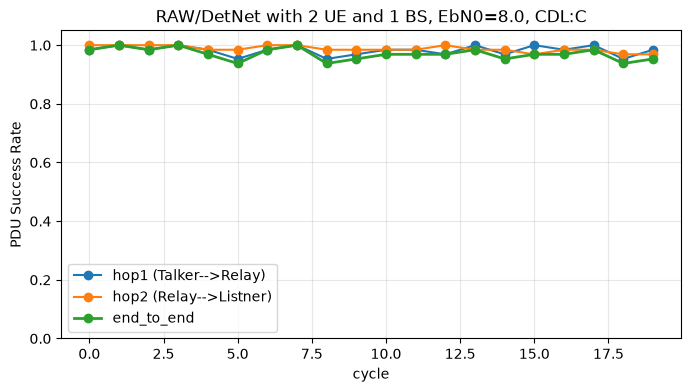

In [7]:
import matplotlib.pyplot as plt

e2e = [r["end_to_end_success_rate"] for r in results]
hop1 = [r["hop1_success_rate"] for r in results]
hop2 = [r["hop2_success_rate"] for r in results]


plt.figure(figsize=(8,4))
plt.plot(hop1, marker="o", label="hop1 (Talker-->Relay)")
plt.plot(hop2, marker="o", label="hop2 (Relay-->Listner)")
plt.plot(e2e, marker="o", label="end_to_end", linewidth=2)
plt.xlabel("cycle")
plt.ylabel("PDU Success Rate")
plt.ylim(0, 1.05)
plt.legend()
plt.title(f"RAW/DetNet with 2 UE and 1 BS, EbN0={EBN0_DB}, CDL:{CDL_MODEL}")
plt.grid(alpha=0.3)
plt.show()


In [8]:
#We can convert the fixed 2 slots DetNet cycle into realistic latency value
ofdm_symbol_duration = RESOURCE_GRID.ofdm_symbol_duration
slot_duration = NUM_OFDM_SYMBOLS * ofdm_symbol_duration
end_to_end_latencys = 2*slot_duration

print (f"OFDM Symbol Duration with CP: {ofdm_symbol_duration*1e6:.3f} us")
print (f"Slot Duration: {slot_duration*1e6} us")
print (f"End_to_End Latency: {end_to_end_latencys*1e6:.3f}us")


for r in results:
    r["end_to_end_latencys"]=end_to_end_latencys


for cycle, stats in enumerate (results):
    print (f"cycle{cycle:2d} | end_to_end: ok:{stats['end_to_end_success_rate']*100:5.1f}%"
          f"|latency: {stats['end_to_end_latencys']*1e3:4f}ms"
          f"({stats['end_to_end_latency_slots']} slots)")
    

OFDM Symbol Duration with CP: 35.965 us
Slot Duration: 503.5087719298246 us
End_to_End Latency: 1007.018us
cycle 0 | end_to_end: ok: 98.4%|latency: 1.007018ms(2 slots)
cycle 1 | end_to_end: ok:100.0%|latency: 1.007018ms(2 slots)
cycle 2 | end_to_end: ok: 98.4%|latency: 1.007018ms(2 slots)
cycle 3 | end_to_end: ok:100.0%|latency: 1.007018ms(2 slots)
cycle 4 | end_to_end: ok: 96.9%|latency: 1.007018ms(2 slots)
cycle 5 | end_to_end: ok: 93.8%|latency: 1.007018ms(2 slots)
cycle 6 | end_to_end: ok: 98.4%|latency: 1.007018ms(2 slots)
cycle 7 | end_to_end: ok:100.0%|latency: 1.007018ms(2 slots)
cycle 8 | end_to_end: ok: 93.8%|latency: 1.007018ms(2 slots)
cycle 9 | end_to_end: ok: 95.3%|latency: 1.007018ms(2 slots)
cycle10 | end_to_end: ok: 96.9%|latency: 1.007018ms(2 slots)
cycle11 | end_to_end: ok: 96.9%|latency: 1.007018ms(2 slots)
cycle12 | end_to_end: ok: 96.9%|latency: 1.007018ms(2 slots)
cycle13 | end_to_end: ok: 98.4%|latency: 1.007018ms(2 slots)
cycle14 | end_to_end: ok: 95.3%|latency

**Step2: Rebundancy--RAW Path Replicatuon and Elimination Mechanism**

-The baseline from step 1 implemented a single path with no protection, if either hop drops the PDU, the transmission failed

-RAW intends to utilize **PAREO (Packet Replicate and Eliminiate)** to replicate the PDU across multiple disjoint paths, then eliminate duplicates at the receiver and accept the PDU if at least one path delivered it correctly.


The topology in step 2 should be:


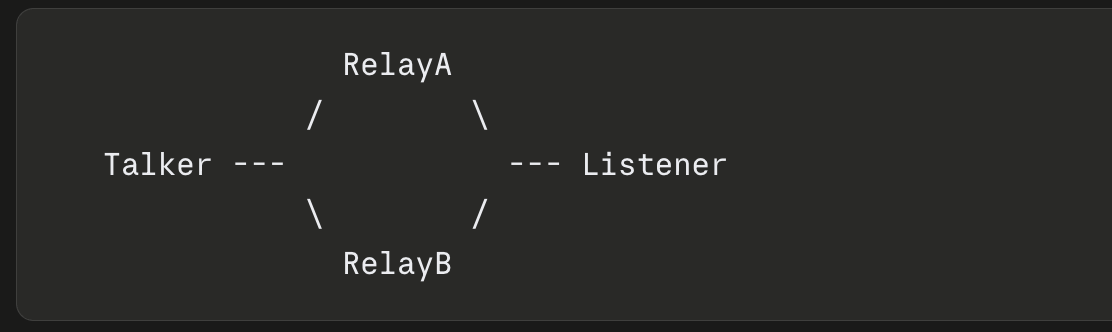


We also need to clearify End_to_End Success is PATH A or Path B, and the resource from Talker remians identical other than adding slots to emphasize the reduancy based on the baseline structure

In [10]:
class RedundantDetNetScheduler:
    """
    The redundancy form RAW is to replicate each PDU over two independent
    paths and remain fixed 2 slots cycle as the baseline has

    Path A: Talker-->Relay A-->Listener
    Path B: Talker-->Relay B--> Listner

    The success delivery is based on EITHER path has PDU arrived
    """

    def __init__(self, batch_size=BATCH_SIZE):
        self.batch_size = batch_size


        #Path A
        self.hop1a=PHYLINK("Talker-->RelayA")
        self.hop2a=PHYLINK("RelayA-->Listener")

        #Path B
        self.hop1b=PHYLINK("Talker-->RelayB")
        self.hop2b=PHYLINK("RelayB-->Listener")


    def run_cycle(self):
        #Slot 0 Talker replicates two PDUs for both relays
        tx_bits, rxA1, okA1 = self.hop1a(self.batch_size)

        _, rxB1, okB1 = self.hop1b(self.batch_size, tx_bits=tx_bits)


        #Slot 1 Each relay fowards the received PDU (Store and Foward)
        _, rxA2, okA2 = self.hop2a(self.batch_size, tx_bits=rxA1)
        _, rxB2, okB2 = self.hop2b(self.batch_size, tx_bits=rxB1)


        path_a_ok = okA1 & okA2
        path_b_ok = okB1 & okB2

        #Elimination: the reciever should only accept the pdu if either path
        end_to_end_ok = path_a_ok | path_b_ok

        return {
            "path_a_success_rate": float(np.mean(path_a_ok)),
            "path_b_success_rate": float(np.mean(path_b_ok)),
            "end_to_end_success_rate": float(np.mean(end_to_end_ok)),
            "end_to_end_latency": 2,
            
        }
        
        
        

Now, we can launch a comparable experiement between baseline and fundamental redundancy model, the seed and number of cycles remain the same

In [12]:
torch.manual_seed (1)

baseline_scheduler = DetNetScheduler(batch_size=BATCH_SIZE)
redundant_scheduler = RedundantDetNetScheduler(batch_size=BATCH_SIZE)

num_cycles = 20
baseline_results = []
redundant_results = []

for cycle in range(num_cycles):
    b_stats = baseline_scheduler.run_cycle()
    r_stats = redundant_scheduler.run_cycle()

    baseline_results.append(b_stats)
    redundant_results.append(r_stats)

    print(f"cycle {cycle:2d} | baseline end to end : {b_stats['end_to_end_success_rate']*100:5.1f}%"
          f"| redundant end to end: {r_stats['end_to_end_success_rate']*100:5.1f}%"
          f"| path A: {r_stats['path_a_success_rate']*100:5.1f}%"
          f"| path B: {r_stats['path_b_success_rate']*100:5.1f}%"
        
    )


cycle  0 | baseline end to end :  98.4%| redundant end to end: 100.0%| path A:  96.9%| path B:  95.3%
cycle  1 | baseline end to end :  96.9%| redundant end to end: 100.0%| path A: 100.0%| path B:  96.9%
cycle  2 | baseline end to end :  95.3%| redundant end to end: 100.0%| path A:  98.4%| path B:  95.3%
cycle  3 | baseline end to end :  96.9%| redundant end to end: 100.0%| path A:  95.3%| path B:  95.3%
cycle  4 | baseline end to end :  98.4%| redundant end to end: 100.0%| path A:  95.3%| path B:  95.3%
cycle  5 | baseline end to end : 100.0%| redundant end to end: 100.0%| path A:  93.8%| path B:  96.9%
cycle  6 | baseline end to end :  93.8%| redundant end to end: 100.0%| path A: 100.0%| path B:  96.9%
cycle  7 | baseline end to end :  90.6%| redundant end to end: 100.0%| path A:  95.3%| path B:  96.9%
cycle  8 | baseline end to end :  96.9%| redundant end to end: 100.0%| path A: 100.0%| path B:  95.3%
cycle  9 | baseline end to end : 100.0%| redundant end to end: 100.0%| path A:  96

We can also plot these results

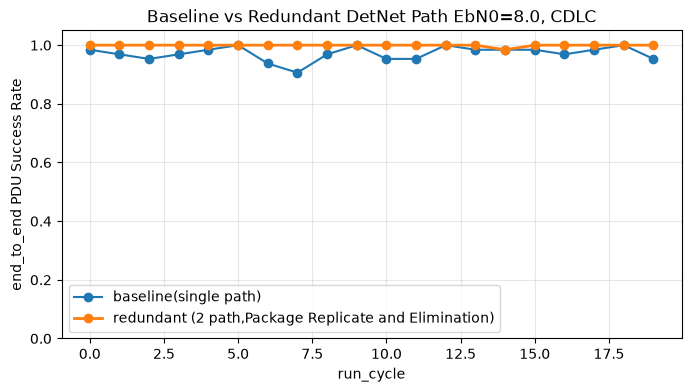

Basline mean end_to_end success:97.19% (PER2.81%)
Redundant mean end_to_end success:99.92% (PER0.08%)
PER reduction factor: 36.0x


In [20]:
baseline_e2e = [r['end_to_end_success_rate'] for r in baseline_results]
redundant_e2e = [r['end_to_end_success_rate'] for r in redundant_results]

plt.figure(figsize=(8,4))
plt.plot(baseline_e2e, marker="o", label="baseline(single path)")
plt.plot(redundant_e2e, marker="o", label="redundant (2 path,Package Replicate and Elimination)",linewidth=2)
plt.xlabel("run_cycle")
plt.ylabel("end_to_end PDU Success Rate")
plt.ylim(0, 1.05)
plt.legend()
plt.title(f"Baseline vs Redundant DetNet Path EbN0={EBN0_DB}, CDL{CDL_MODEL}")
plt.grid(alpha=0.3)
plt.show()

baseline_mean=np.mean(baseline_e2e)
redundant_mean=np.mean(redundant_e2e)
baseline_per=1-baseline_mean
redundant_per=1-redundant_mean

print(f"Basline mean end_to_end success:{baseline_mean*100:.2f}% (PER{baseline_per*100:.2f}%)")
print(f"Redundant mean end_to_end success:{redundant_mean*100:.2f}% (PER{redundant_per*100:.2f}%)")

if redundant_per >0:
    print(f"PER reduction factor: {baseline_per/redundant_per:.1f}x")
else:
    print (f"No End to End failure is observed on the redundant path during this simulation")

        
